In [4]:
import pandas as pd

In [5]:
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('C:\\Users\\tript\\OneDrive\\Desktop\\internsip\\10_benchmark_indices.csv')

In [7]:
df.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   object 
 1   index_name   8050 non-null   object 
 2   close_value  8050 non-null   float64
dtypes: float64(1), object(2)
memory usage: 188.8+ KB


In [9]:
df.describe()

,close_value
count,8050.000000
mean,18351.950181
std,14169.995121
min,1444.130000
25%,2819.062500
50%,18392.960000
75%,26539.097500
max,79075.390000


In [10]:
df.isnull().sum()

date           0
index_name     0
close_value    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
# Convert date to datetime
df["date"] = pd.to_datetime(df["date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         8050 non-null   datetime64[ns]
 1   index_name   8050 non-null   object        
 2   close_value  8050 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 188.8+ KB


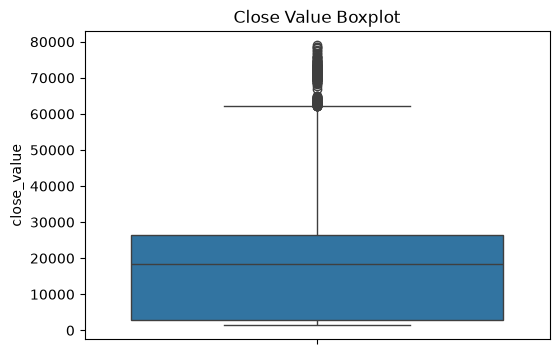

In [15]:
# Boxplot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(y=df["close_value"])
plt.title("Close Value Boxplot")
plt.show()

In [14]:
# IQR Outlier Count

Q1 = df["close_value"].quantile(0.25)
Q3 = df["close_value"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Outliers:", ((df["close_value"] < lower) | (df["close_value"] > upper)).sum())

Outliers: 197


In [16]:
# Observation:
# 'close_value' contains IQR outliers.
# These values represent genuine market highs/lows and are expected
# in benchmark index data. Therefore, no outliers were removed.

In [17]:
df.to_csv("10_benchmark_indices_clean.csv", index=False)